# QUBO Step-by-Step Formulation: Simplified Version

This notebook shows how we build the reduced scheduling QUBO term by term. It is intentionally small and pedagogical.

The goal is not to reproduce the full Seren experiment. The goal is to make the QUBO construction easy to explain:

1. Create binary assignment variables.
2. Add energy cost.
3. Add the assignment penalty.
4. Add the capacity penalty with slack variables.
5. Add an optional peak/load-smoothing penalty.
6. Solve the tiny QUBO with D-Wave's simulated annealing sampler.


## 1. Tiny Instance

We use one cluster and three jobs.

- 3 jobs: `j1`, `j2`, `j3`.
- 3 time slots: `0`, `1`, `2`.
- Each job lasts 1 slot.
- Each job requires 1 resource unit.
- The single cluster has capacity 2.
- Because there are 3 jobs and only 2 resource units, the capacity term can affect the schedule.

The resource unit is called `gpu` in the toy data, but in real experiments it can represent GPU, node, or block depending on preprocessing.


In [1]:
from __future__ import annotations

from dataclasses import dataclass, field
from itertools import combinations
from math import ceil, log2

import matplotlib.pyplot as plt
import pandas as pd

try:
    import dimod
except ImportError:
    dimod = None

try:
    from dwave.samplers import SimulatedAnnealingSampler
except ImportError:
    SimulatedAnnealingSampler = None

jobs = pd.DataFrame([
    {"job_id": "j1", "duration": 1, "earliest_start": 0, "latest_start": 1, "gpu": 1, "power_mw": 0.010},
    {"job_id": "j2", "duration": 1, "earliest_start": 0, "latest_start": 2, "gpu": 1, "power_mw": 0.015},
    {"job_id": "j3", "duration": 1, "earliest_start": 0, "latest_start": 2, "gpu": 1, "power_mw": 0.008},
])

clusters = pd.DataFrame([
    {"cluster_id": "c_main", "gpu_capacity": 2},
])

hours = [0, 1, 2]
price = {0: 30.0, 1: 100.0, 2: 40.0}  # effective QUBO price, not necessarily raw grid price
delta_t = 1.0
pue = {0: 1.20, 1: 1.20, 2: 1.20}

weights = {
    "assignment": 200.0,
    "capacity": 80.0,
    "peak": 5000.0,
}

jobs


Matplotlib created a temporary cache directory at /var/folders/kj/srm136c14rq3h_h76tdm02700000gn/T/matplotlib-50hr7a_x because the default path (/Users/juanparrado/.matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


,job_id,duration,earliest_start,latest_start,gpu,power_mw
0,j1,1,0,1,1,0.010
1,j2,1,0,2,1,0.015
2,j3,1,0,2,1,0.008


## 2. QUBO State and Generic Square Penalty

A QUBO has this form:

$$
H(z) = q_0 + \sum_i q_i z_i + \sum_{i<j}q_{ij}z_iz_j
$$

The helper `add_squared_penalty` converts an equality into QUBO coefficients:

$$
\lambda\left(\sum_i a_i z_i - b\right)^2
$$

This one helper is reused for assignment, capacity, and peak/load-smoothing terms.


In [2]:
@dataclass
class QuboState:
    offset: float = 0.0
    linear: dict[int, float] = field(default_factory=dict)
    quadratic: dict[tuple[int, int], float] = field(default_factory=dict)
    variables: list[dict] = field(default_factory=list)


def add_linear(state: QuboState, idx: int, coefficient: float) -> None:
    if coefficient:
        state.linear[idx] = state.linear.get(idx, 0.0) + float(coefficient)


def add_quadratic(state: QuboState, i: int, j: int, coefficient: float) -> None:
    if i == j:
        add_linear(state, i, coefficient)
        return
    key = (i, j) if i < j else (j, i)
    if coefficient:
        state.quadratic[key] = state.quadratic.get(key, 0.0) + float(coefficient)


def add_squared_penalty(state: QuboState, terms: dict[int, float], rhs: float, weight: float) -> None:
    """Add weight * (sum_i terms_i z_i - rhs)^2 to the QUBO."""
    state.offset += weight * rhs * rhs
    indices = list(terms)
    for idx, coeff in terms.items():
        add_linear(state, idx, weight * (coeff * coeff - 2.0 * rhs * coeff))
    for pos, i in enumerate(indices):
        for j in indices[pos + 1:]:
            add_quadratic(state, i, j, 2.0 * weight * terms[i] * terms[j])


def qubo_summary(state: QuboState) -> dict:
    return {
        "variables": len(state.variables),
        "linear_terms": len(state.linear),
        "quadratic_terms": len(state.quadratic),
        "offset": state.offset,
    }


## 3. Assignment Variables

Create one binary variable per feasible start option:

$$
x_{i,s}=1
$$

means job `i` starts at slot `s` in the single cluster.

Since there is only one cluster, we keep the cluster field only for consistency with the real implementation.


In [3]:
def feasible_starts(job: pd.Series) -> list[int]:
    return list(range(int(job.earliest_start), int(job.latest_start) + 1))


def add_assignment_variables(state: QuboState, jobs_df: pd.DataFrame, clusters_df: pd.DataFrame) -> None:
    cluster_id = str(clusters_df.iloc[0].cluster_id)
    for _, job in jobs_df.iterrows():
        for start in feasible_starts(job):
            state.variables.append({
                "type": "assignment",
                "job_id": job.job_id,
                "cluster_id": cluster_id,
                "start": int(start),
                "duration": int(job.duration),
                "gpu": float(job.gpu),
                "power_mw": float(job.power_mw),
            })


state = QuboState()
add_assignment_variables(state, jobs, clusters)
assignment_variable_count = len(state.variables)
pd.DataFrame(state.variables)


,type,job_id,cluster_id,start,duration,gpu,power_mw
0,assignment,j1,c_main,0,1,1.0,0.010
1,assignment,j1,c_main,1,1,1.0,0.010
2,assignment,j2,c_main,0,1,1.0,0.015
3,assignment,j2,c_main,1,1,1.0,0.015
4,assignment,j2,c_main,2,1,1.0,0.015
5,assignment,j3,c_main,0,1,1.0,0.008
6,assignment,j3,c_main,1,1,1.0,0.008
7,assignment,j3,c_main,2,1,1.0,0.008


## 4. Validation and Solver Helpers

The checks are intentionally simple:

- every job must appear exactly once;
- capacity must not be exceeded in any time slot.


In [4]:
def is_active(start: int, duration: int, hour: int) -> bool:
    return start <= hour <= start + duration - 1


def clone_state_with_same_variables(source: QuboState) -> QuboState:
    return QuboState(variables=[dict(variable) for variable in source.variables])


def to_dimod_bqm(state: QuboState):
    if dimod is None:
        raise ImportError("dimod is not installed")
    bqm = dimod.BinaryQuadraticModel({}, {}, state.offset, dimod.BINARY)
    for idx, coeff in state.linear.items():
        bqm.add_variable(idx, coeff)
    for (i, j), coeff in state.quadratic.items():
        bqm.add_interaction(i, j, coeff)
    return bqm


def decode_schedule(state: QuboState, sample: dict[int, int]) -> pd.DataFrame:
    rows = []
    for idx, bit in sample.items():
        if bit != 1:
            continue
        var = state.variables[idx]
        if var["type"] == "assignment":
            rows.append({"var": idx, **var})
    return pd.DataFrame(rows)


def solve_with_dwave_simulator(state: QuboState, reads: int = 5000, seed: int = 42) -> dict:
    if SimulatedAnnealingSampler is None:
        raise ImportError("dwave.samplers is not installed")
    sampleset = SimulatedAnnealingSampler().sample(to_dimod_bqm(state), num_reads=reads, seed=seed)
    best = sampleset.first
    sample = {int(var): int(value) for var, value in best.sample.items()}
    return {"energy": float(best.energy), "sample": sample, "schedule": decode_schedule(state, sample)}


def validate_schedule(schedule: pd.DataFrame, jobs_df: pd.DataFrame, clusters_df: pd.DataFrame, hours: list[int]) -> dict:
    assignment_counts = schedule["job_id"].value_counts() if not schedule.empty else pd.Series(dtype=int)
    assignment_violations = sum(int(assignment_counts.get(job_id, 0)) != 1 for job_id in jobs_df["job_id"])

    cluster_capacity = float(clusters_df.iloc[0].gpu_capacity)
    capacity_violation = 0.0
    for hour in hours:
        used = 0.0
        if not schedule.empty:
            for row in schedule.itertuples(index=False):
                if is_active(int(row.start), int(row.duration), hour):
                    used += float(row.gpu)
        capacity_violation += max(0.0, used - cluster_capacity)

    return {
        "assignments": len(schedule),
        "unique_jobs": int(schedule["job_id"].nunique()) if not schedule.empty else 0,
        "assignment_violations": int(assignment_violations),
        "capacity_violation_total": float(capacity_violation),
    }


def solve_and_report(label: str, state: QuboState) -> dict:
    result = solve_with_dwave_simulator(state)
    validation = validate_schedule(result["schedule"], jobs, clusters, hours)
    summary = {"stage": label, "energy": result["energy"], **qubo_summary(state), **validation}
    display(pd.DataFrame([summary]))
    display(result["schedule"])
    return {"summary": summary, **result}


## 5. Energy Cost Term

Energy cost is a linear QUBO term.

For each assignment variable, we add:

$$
E_{i,s}=\sum_t c_t \cdot PUE_t \cdot p_i \cdot a_{i,s,t}\cdot \Delta t
$$

where `c_t` is the effective QUBO price and `a_{i,s,t}` is 1 if the job is active at time `t`.

With only this term, the best solution is usually to schedule nothing, because every selected job adds positive cost.


In [5]:
def add_energy_cost(state: QuboState) -> None:
    for idx, var in enumerate(state.variables):
        if var["type"] != "assignment":
            continue
        cost = 0.0
        for hour in hours:
            if is_active(var["start"], var["duration"], hour):
                cost += price[hour] * pue[hour] * var["power_mw"] * delta_t
        add_linear(state, idx, cost)


state = clone_state_with_same_variables(state)
add_energy_cost(state)
cost_only_result = solve_and_report("1_energy_only", state)


,stage,energy,variables,linear_terms,quadratic_terms,offset,assignments,unique_jobs,assignment_violations,capacity_violation_total
0,1_energy_only,0.0,8,8,0,0.0,0,0,3,0.0


""


## 6. Assignment Penalty

Each job must be scheduled exactly once:

$$
\sum_{s\in S_i}x_{i,s}=1
$$

QUBO penalty:

$$
H_A=\lambda_A\sum_i\left(\sum_{s\in S_i}x_{i,s}-1\right)^2
$$

This creates a dense interaction between the feasible options of the same job. Selecting two starts for the same job becomes expensive.


In [6]:
def add_assignment_penalty(state: QuboState, weight: float) -> None:
    for job_id in jobs["job_id"]:
        terms = {
            idx: 1.0
            for idx, var in enumerate(state.variables)
            if var["type"] == "assignment" and var["job_id"] == job_id
        }
        add_squared_penalty(state, terms, rhs=1.0, weight=weight)


add_assignment_penalty(state, weights["assignment"])
assignment_result = solve_and_report("2_energy_assignment", state)


,stage,energy,variables,linear_terms,quadratic_terms,offset,assignments,unique_jobs,assignment_violations,capacity_violation_total
0,2_energy_assignment,1.188,8,8,7,600.0,3,3,0,1.0


,var,type,job_id,cluster_id,start,duration,gpu,power_mw
0,0,assignment,j1,c_main,0,1,1.0,0.010
1,2,assignment,j2,c_main,0,1,1.0,0.015
2,5,assignment,j3,c_main,0,1,1.0,0.008


## 7. Capacity Penalty with Slack Variables

The cluster capacity constraint is:

$$
D_t(x) \le G
$$

QUBO handles inequalities by adding unused-capacity slack:

$$
D_t(x)+Y_t=G
$$

The slack is binary encoded:

$$
Y_t=\sum_b2^b y_{t,b}
$$

Penalty:

$$
H_G=\lambda_G\sum_t\left(D_t(x)+\sum_b2^b y_{t,b}-G\right)^2
$$

If demand is below capacity, slack can represent unused capacity. If demand exceeds capacity, no non-negative slack can repair the equality.


In [7]:
def add_capacity_penalty_with_slack(state: QuboState, weight: float) -> None:
    G = int(clusters.iloc[0].gpu_capacity)
    bits = max(1, ceil(log2(G + 1)))
    cluster_id = str(clusters.iloc[0].cluster_id)

    for hour in hours:
        terms = {}
        for idx, var in enumerate(state.variables):
            if var["type"] != "assignment":
                continue
            if is_active(var["start"], var["duration"], hour):
                terms[idx] = float(var["gpu"])

        if not terms:
            continue

        for bit in range(bits):
            slack_idx = len(state.variables)
            coefficient = float(2 ** bit)
            state.variables.append({
                "type": "capacity_slack",
                "cluster_id": cluster_id,
                "hour": hour,
                "bit": bit,
                "coefficient": coefficient,
            })
            terms[slack_idx] = coefficient

        add_squared_penalty(state, terms, rhs=float(G), weight=weight)


variables_before_slack = len(state.variables)
add_capacity_penalty_with_slack(state, weights["capacity"])
capacity_result = solve_and_report("3_energy_assignment_capacity", state)
{"slack_variables_added": len(state.variables) - variables_before_slack, **qubo_summary(state)}


,stage,energy,variables,linear_terms,quadratic_terms,offset,assignments,unique_jobs,assignment_violations,capacity_violation_total
0,3_energy_assignment_capacity,1.284,14,14,33,1560.0,3,3,0,0.0


,var,type,job_id,cluster_id,start,duration,gpu,power_mw
0,0,assignment,j1,c_main,0,1,1.0,0.010
1,2,assignment,j2,c_main,0,1,1.0,0.015
2,7,assignment,j3,c_main,2,1,1.0,0.008


{'slack_variables_added': 6,
 'variables': 14,
 'linear_terms': 14,
 'quadratic_terms': 33,
 'offset': 1560.0}

## 8. Optional Peak / Load-Smoothing Term

This is not exact contracted-power billing. It is a QUBO-compatible proxy that discourages concentrating too much facility load in one slot:

$$
H_P=\lambda_P\sum_t\left(PUE_t\cdot L^{IT}_t(x)\right)^2
$$

Because load is linear in assignment variables, its square is still quadratic.


In [8]:
def add_peak_smoothing_penalty(state: QuboState, weight: float) -> None:
    for hour in hours:
        terms = {}
        for idx, var in enumerate(state.variables):
            if var["type"] != "assignment":
                continue
            if is_active(var["start"], var["duration"], hour):
                terms[idx] = pue[hour] * float(var["power_mw"])
        if terms:
            add_squared_penalty(state, terms, rhs=0.0, weight=weight)


add_peak_smoothing_penalty(state, weights["peak"])
final_result = solve_and_report("4_full_qubo", state)


,stage,energy,variables,linear_terms,quadratic_terms,offset,assignments,unique_jobs,assignment_violations,capacity_violation_total
0,4_full_qubo,4.8408,14,14,33,1560.0,3,3,0,0.0


,var,type,job_id,cluster_id,start,duration,gpu,power_mw
0,0,assignment,j1,c_main,0,1,1.0,0.010
1,4,assignment,j2,c_main,2,1,1.0,0.015
2,6,assignment,j3,c_main,1,1,1.0,0.008


## 9. Final QUBO Coefficients

The final QUBO contains assignment variables and slack variables. Linear coefficients contain energy and penalty contributions. Quadratic coefficients contain interactions created by assignment, capacity, and peak/load-smoothing penalties.


In [9]:
linear_df = pd.DataFrame([
    {"var": idx, "coefficient": coeff, **state.variables[idx]}
    for idx, coeff in sorted(state.linear.items())
])
quadratic_df = pd.DataFrame([
    {"left": i, "right": j, "coefficient": coeff}
    for (i, j), coeff in sorted(state.quadratic.items())
])

print("QUBO summary")
display(pd.DataFrame([qubo_summary(state)]))
print("Linear coefficients")
display(linear_df.head(12))
print("Quadratic coefficients")
display(quadratic_df.head(12))


QUBO summary


,variables,linear_terms,quadratic_terms,offset
0,14,14,33,1560.0


Linear coefficients


,var,coefficient,type,job_id,cluster_id,start,duration,gpu,power_mw,hour,bit
0,0,-438.9200,assignment,j1,c_main,0.0,1.0,1.0,0.010,NaN,NaN
1,1,-438.0800,assignment,j1,c_main,1.0,1.0,1.0,0.010,NaN,NaN
2,2,-437.8400,assignment,j2,c_main,0.0,1.0,1.0,0.015,NaN,NaN
3,3,-436.5800,assignment,j2,c_main,1.0,1.0,1.0,0.015,NaN,NaN
4,4,-437.6600,assignment,j2,c_main,2.0,1.0,1.0,0.015,NaN,NaN
5,5,-439.2512,assignment,j3,c_main,0.0,1.0,1.0,0.008,NaN,NaN
6,6,-438.5792,assignment,j3,c_main,1.0,1.0,1.0,0.008,NaN,NaN
7,7,-439.1552,assignment,j3,c_main,2.0,1.0,1.0,0.008,NaN,NaN
8,8,1.0000,capacity_slack,NaN,c_main,NaN,NaN,NaN,NaN,0.0,0.0
9,9,2.0000,capacity_slack,NaN,c_main,NaN,NaN,NaN,NaN,0.0,1.0


Quadratic coefficients


,left,right,coefficient
0,0,1,400.000
1,0,2,162.160
2,0,5,161.152
3,0,8,160.000
4,0,9,320.000
5,1,3,162.160
6,1,6,161.152
7,1,10,160.000
8,1,11,320.000
9,2,3,400.000


## 10. Interaction Graph

A QUBO can be viewed as a graph:

- nodes are binary variables;
- edges are quadratic interactions.

Dense regions are harder for quantum annealing hardware because they require more couplers and harder embeddings.


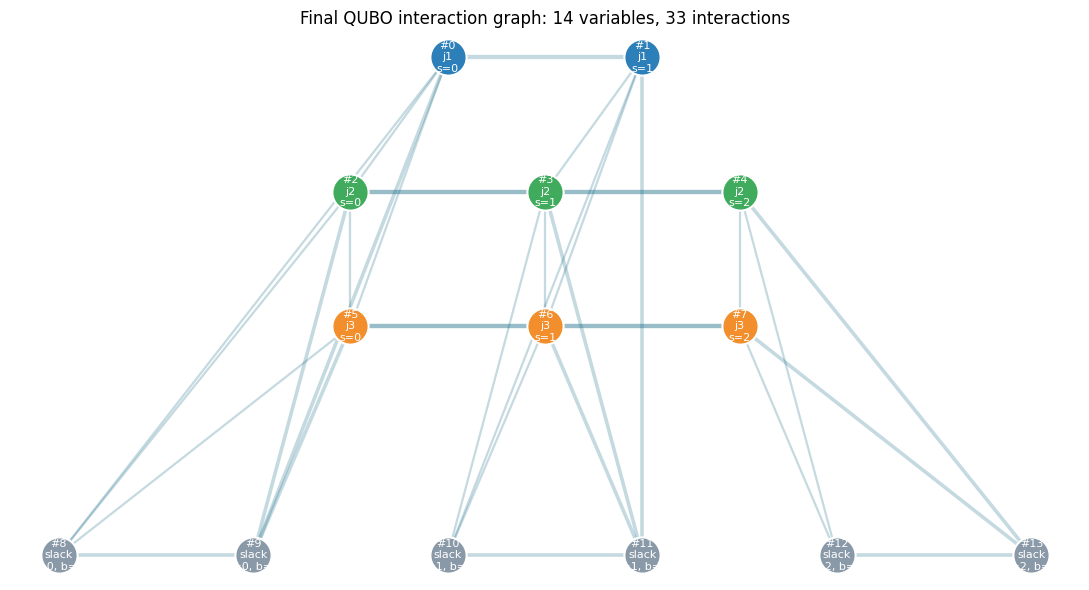

In [10]:
def variable_label(idx: int, var: dict) -> str:
    if var["type"] == "assignment":
        return f"#{idx}\n{var['job_id']}\ns={var['start']}"
    return f"#{idx}\nslack\nt={var['hour']}, b={var['bit']}"


def variable_color(var: dict) -> str:
    if var["type"] != "assignment":
        return "#8a99a8"
    return {"j1": "#2c7fb8", "j2": "#41ab5d", "j3": "#f28e2b"}.get(var["job_id"], "#756bb1")


def plot_interaction_graph(state: QuboState) -> None:
    assignment_indices = [idx for idx, var in enumerate(state.variables) if var["type"] == "assignment"]
    slack_indices = [idx for idx, var in enumerate(state.variables) if var["type"] != "assignment"]

    positions = {}
    for row, job_id in enumerate(jobs["job_id"]):
        indices = [idx for idx in assignment_indices if state.variables[idx]["job_id"] == job_id]
        x0 = -(len(indices) - 1) / 2
        for col, idx in enumerate(indices):
            positions[idx] = (x0 + col, 1.2 - row)
    for col, idx in enumerate(slack_indices):
        positions[idx] = (col - (len(slack_indices) - 1) / 2, -2.5)

    fig, ax = plt.subplots(figsize=(11, 6))
    edge_items = [((i, j), coeff) for (i, j), coeff in state.quadratic.items() if abs(coeff) > 1e-12]
    max_abs = max((abs(coeff) for _, coeff in edge_items), default=1.0)
    for (i, j), coeff in edge_items:
        x1, y1 = positions[i]
        x2, y2 = positions[j]
        ax.plot([x1, x2], [y1, y2], color="#176b87" if coeff > 0 else "#9f3a38", linewidth=0.6 + 2.5 * abs(coeff) / max_abs, alpha=0.25)

    for idx, var in enumerate(state.variables):
        x, y = positions[idx]
        ax.scatter([x], [y], s=680, color=variable_color(var), edgecolor="white", linewidth=1.5, zorder=2)
        ax.text(x, y, variable_label(idx, var), ha="center", va="center", fontsize=8, color="white", zorder=3)

    ax.set_title(f"Final QUBO interaction graph: {len(state.variables)} variables, {len(edge_items)} interactions")
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()


plot_interaction_graph(state)


## 11. Size Scaling Intuition

For one cluster, assignment variables grow as:

$$
N_x=\sum_i |S_i|
$$

where `S_i` is the feasible start set of job `i`.

The assignment penalty creates a clique among the options of each job. If a job has `m` options, it creates:

$$
\binom{m}{2}
$$

quadratic interactions.

Capacity also adds slack variables. Larger capacity and longer horizons increase the number of slack bits and capacity interactions.


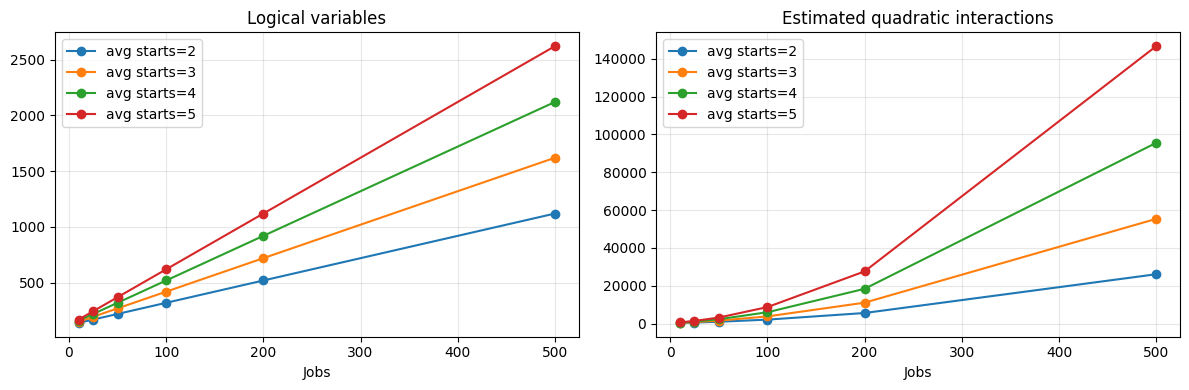

,jobs,avg_starts,horizon,capacity,assignment_variables,slack_variables,total_variables,assignment_couplers,capacity_couplers_est,total_couplers_est
0,10,2,24,16,20,120,140,10,338,348
1,25,2,24,16,50,120,170,25,517,542
2,50,2,24,16,100,120,220,50,898,948
3,100,2,24,16,200,120,320,100,1973,2073
4,200,2,24,16,400,120,520,200,5373,5573
5,500,2,24,16,1000,120,1120,500,25573,26073
6,10,3,24,16,30,120,150,30,394,424
7,25,3,24,16,75,120,195,75,695,770


In [11]:
def n_choose_2(value: int | float) -> float:
    return float(value * (value - 1) / 2)


def estimate_one_cluster_qubo_size(num_jobs: int, average_starts: int, horizon_slots: int, capacity: int) -> dict:
    assignment_variables = num_jobs * average_starts
    assignment_couplers = num_jobs * n_choose_2(average_starts)
    slack_bits_per_time = max(1, ceil(log2(capacity + 1)))
    slack_variables = horizon_slots * slack_bits_per_time

    active_assignments_per_time = num_jobs * average_starts / horizon_slots
    capacity_couplers = horizon_slots * (
        n_choose_2(active_assignments_per_time)
        + active_assignments_per_time * slack_bits_per_time
        + n_choose_2(slack_bits_per_time)
    )
    return {
        "jobs": num_jobs,
        "avg_starts": average_starts,
        "horizon": horizon_slots,
        "capacity": capacity,
        "assignment_variables": int(assignment_variables),
        "slack_variables": int(slack_variables),
        "total_variables": int(assignment_variables + slack_variables),
        "assignment_couplers": int(assignment_couplers),
        "capacity_couplers_est": int(round(capacity_couplers)),
        "total_couplers_est": int(round(assignment_couplers + capacity_couplers)),
    }


scaling_df = pd.DataFrame([
    estimate_one_cluster_qubo_size(num_jobs, average_starts=starts, horizon_slots=24, capacity=16)
    for starts in [2, 3, 4, 5]
    for num_jobs in [10, 25, 50, 100, 200, 500]
])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for starts in [2, 3, 4, 5]:
    data = scaling_df[scaling_df["avg_starts"] == starts]
    axes[0].plot(data["jobs"], data["total_variables"], marker="o", label=f"avg starts={starts}")
    axes[1].plot(data["jobs"], data["total_couplers_est"], marker="o", label=f"avg starts={starts}")
axes[0].set_title("Logical variables")
axes[1].set_title("Estimated quadratic interactions")
for ax in axes:
    ax.set_xlabel("Jobs")
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

scaling_df.head(8)


## 12. Takeaway

The reduced QUBO is built from a small number of ideas:

- assignment variables choose start times;
- energy is a linear cost;
- assignment feasibility is a squared one-hot penalty;
- capacity is an inequality converted into equality with slack bits;
- peak/load smoothing is an optional quadratic proxy.

The construction is simple in principle, but the number of variables and interactions grows quickly as we increase jobs, feasible starts, horizon length, and capacity.
